## using BOW , tf-idf, Ml algorithm

# impoting data

In [2]:
import pandas as pd
df = pd.read_csv('../Data_Set/SMSSpamCollection.txt', sep='\t', header=None, names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### text preprocessing

In [10]:
from text_preprocessing import preprocess_text
from text_preprocessing import to_lower, remove_email, remove_url, remove_punctuation, lemmatize_word


In [11]:
from text_preprocessing import (
    preprocess_text,
    to_lower,
    remove_email,
    remove_url,
    remove_punctuation,
    remove_stopword,
    lemmatize_word,
    
)

custom_pipeline = [
    to_lower,
    remove_email,
    remove_url,
    remove_punctuation,
    remove_stopword,
    lemmatize_word
]

df["processed_message"] = df["message"].astype(str).apply(
    lambda x: preprocess_text(x, custom_pipeline)
)

In [12]:
df.head()

,label,message,processed_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


### creat bag of words

In [17]:
y=pd.get_dummies(df['label'])
y=y.iloc[:,0].values
y

array([ True,  True, False, ...,  True,  True,  True], shape=(5572,))

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['processed_message'], y, test_size=0.2, random_state=42)

In [ ]:
X_train


1978    reply win £100 weekly 2006 fifa world cup held...
3989    hello sort town already dont rush home eating ...
3935                        come guoyang go n tell u told
4078    hey sathya till dint meet even single time saw...
4086    orange brings ringtones time chart hero free h...
                              ...                        
3772    hi wlcome back wonder got eaten lion something...
5191                                 sorry ill call later
5226                prabhaim sorydarealyfrm heart im sory
5390                             nt joking seriously told
860                              say somebody named tampa
Name: processed_message, Length: 4457, dtype: str

In [ ]:
y_train


array([False,  True,  True, ...,  True,  True,  True], shape=(4457,))

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
vc=CountVectorizer()
X_train_vec=vc.fit_transform(X_train).toarray()
X_train_vec

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4457, 7763))

In [26]:
X_test_vec=vc.transform(X_test).toarray()
X_test_vec

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1115, 7763))

In [27]:
vc.vocabulary_

{'reply': 5743,
 'win': 7511,
 '100': 251,
 'weekly': 7433,
 '2006': 382,
 'fifa': 2830,
 'world': 7591,
 'cup': 2145,
 'held': 3382,
 'send': 6027,
 'stop': 6505,
 '87239': 756,
 'end': 2609,
 'service': 6048,
 'hello': 3386,
 'sort': 6350,
 'town': 6991,
 'already': 991,
 'dont': 2445,
 'rush': 5877,
 'home': 3475,
 'eating': 2546,
 'nacho': 4705,
 'let': 4120,
 'know': 3987,
 'eta': 2660,
 'come': 1951,
 'guoyang': 3282,
 'go': 3158,
 'tell': 6744,
 'told': 6933,
 'hey': 3416,
 'sathya': 5931,
 'till': 6884,
 'dint': 2376,
 'meet': 4448,
 'even': 2673,
 'single': 6192,
 'time': 6885,
 'saw': 5946,
 'situation': 6207,
 'orange': 5033,
 'brings': 1558,
 'ringtones': 5820,
 'chart': 1787,
 'hero': 3409,
 'free': 2977,
 'hit': 3438,
 'week': 7431,
 'pic': 5238,
 'wap': 7375,
 'receiving': 5661,
 'tip': 6893,
 'sitting': 6206,
 'mu': 4663,
 'waiting': 7350,
 'everyone': 2684,
 'get': 3115,
 'suite': 6590,
 'take': 6686,
 'shower': 6145,
 'finish': 2856,
 'liao': 4124,
 'urgent': 7196,
 '

In [28]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train_vec, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [29]:
y_pred=model.predict(X_test_vec)
y_pred

array([ True,  True,  True, ...,  True,  True,  True], shape=(1115,))

In [31]:
from sklearn.metrics import accuracy_score,classification_report
accuracy_score(y_test, y_pred)



0.9856502242152466

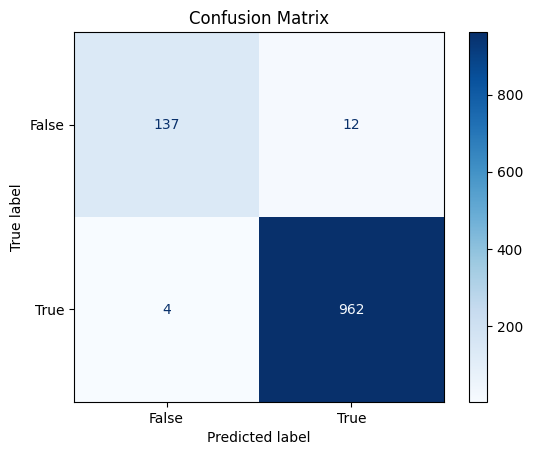

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### Creating The TF-IDF Model

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['processed_message'], y, test_size=0.2, random_state=42)


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
X_train_vec=tfidf.fit_transform(X_train).toarray()
X_train_vec

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(4457, 7763))

In [35]:
x_test_vec=tfidf.transform(X_test).toarray()
x_test_vec

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1115, 7763))

In [36]:
tfidf.vocabulary_

{'reply': 5743,
 'win': 7511,
 '100': 251,
 'weekly': 7433,
 '2006': 382,
 'fifa': 2830,
 'world': 7591,
 'cup': 2145,
 'held': 3382,
 'send': 6027,
 'stop': 6505,
 '87239': 756,
 'end': 2609,
 'service': 6048,
 'hello': 3386,
 'sort': 6350,
 'town': 6991,
 'already': 991,
 'dont': 2445,
 'rush': 5877,
 'home': 3475,
 'eating': 2546,
 'nacho': 4705,
 'let': 4120,
 'know': 3987,
 'eta': 2660,
 'come': 1951,
 'guoyang': 3282,
 'go': 3158,
 'tell': 6744,
 'told': 6933,
 'hey': 3416,
 'sathya': 5931,
 'till': 6884,
 'dint': 2376,
 'meet': 4448,
 'even': 2673,
 'single': 6192,
 'time': 6885,
 'saw': 5946,
 'situation': 6207,
 'orange': 5033,
 'brings': 1558,
 'ringtones': 5820,
 'chart': 1787,
 'hero': 3409,
 'free': 2977,
 'hit': 3438,
 'week': 7431,
 'pic': 5238,
 'wap': 7375,
 'receiving': 5661,
 'tip': 6893,
 'sitting': 6206,
 'mu': 4663,
 'waiting': 7350,
 'everyone': 2684,
 'get': 3115,
 'suite': 6590,
 'take': 6686,
 'shower': 6145,
 'finish': 2856,
 'liao': 4124,
 'urgent': 7196,
 '

In [38]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [39]:
y_pred=model.predict(X_test_vec)
y_pred

array([ True,  True,  True, ...,  True,  True,  True], shape=(1115,))

In [40]:
score=accuracy_score(y_test,y_pred)
print(score)

0.9811659192825112


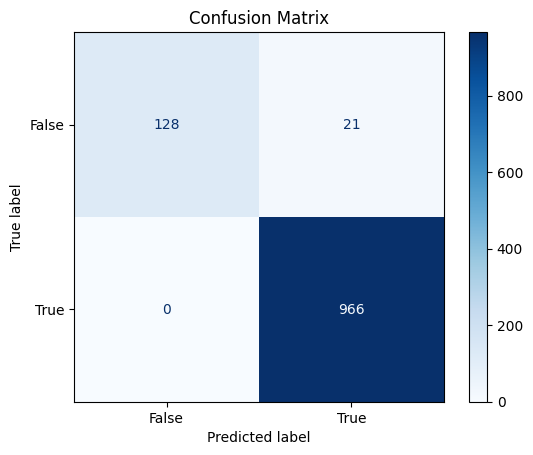

In [41]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()